# Experiment 5: K-Nearest Neighbors (KNN)

**Course:** 23CSE301 — Machine Learning Lab  
**Topic:** K-Nearest Neighbors Classifier with Minkowski distance  
**Dataset:** `datasets/Breast_Cancer_Detection_Classification_Master.csv` (Wisconsin Diagnostic Breast Cancer — 569 rows, 32 columns)  
**Lab Book Reference:** §9 K-Nearest Neighbors, page 38–43

---

## 🎯 Objective

Implement the **K-Nearest Neighbors** algorithm for binary classification on
the Wisconsin Diagnostic Breast Cancer (WDBC) dataset.  We sweep the number of
neighbors `K ∈ {1, 2, 3, 4, 5}` and choose the model with the best test
accuracy.  We use the **Minkowski** distance with `p = 2` (equivalent to
Euclidean distance).

## 🧠 Key Concepts

- **Lazy learning:** KNN has no explicit training phase — it simply memorises
  the training set and computes distances at prediction time.
- **Distance metric:** Euclidean (p=2) is the default; Minkowski with `p=1`
  is Manhattan distance.
- **Choice of K:** small K → low bias, high variance (overfitting); large K →
  high bias, low variance (under-fitting).  Typical heuristic: `K = √N`.
- **Feature scaling:** KNN depends critically on Euclidean distance, so
  features must be standardized before training.
- **Majority vote:** for classification, the new sample's class is the most
  common label among its K nearest neighbors.

## ▶️ How to Run

> **Option A — Google Colab (recommended):**
> 1. Upload the entire `ML-Lab-Activities` folder to Google Drive.
> 2. Open `05-KNN/05_KNN_Classifier.ipynb` from Drive in Colab.
> 3. The first cell mounts Drive, sets the working directory, and creates the
>    `outputs/` subfolder.
>
> **Option B — Local Jupyter:**
> ```bash
> pip install -r requirements.txt
> jupyter notebook 05-KNN/05_KNN_Classifier.ipynb
> ```
>
> **Option C — Headless:**
> ```bash
> jupyter nbconvert --to notebook --execute \
>   05-KNN/05_KNN_Classifier.ipynb --output 05_KNN_Classifier.ipynb
> ```

Datasets are read from `datasets/` (relative to the notebook's folder).
Generated figures are **auto-saved** to `./outputs/`.


In [1]:
# === Environment setup (works in both Google Colab and local Jupyter) ===
import os, sys

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE = '/content/drive/MyDrive/ML-Lab-Activities-Complete'
    os.chdir(os.path.join(BASE, '05-KNN'))
    print(f'Running in Google Colab. CWD: {os.getcwd()}')
else:
    print(f'Running locally. CWD: {os.getcwd()}')

OUTPUT_DIR = os.path.join(os.getcwd(), 'outputs')
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Patch plt.show so every figure is also auto-saved as PNG
import matplotlib.pyplot as plt
_fig_counter = [0]
_orig_plt_show = plt.show
def _save_and_show(*args, **kwargs):
    for fnum in plt.get_fignums():
        _fig_counter[0] += 1
        fig = plt.figure(fnum)
        fname = f'figure_{_fig_counter[0]:03d}.png'
        try:
            fig.savefig(os.path.join(OUTPUT_DIR, fname), dpi=120, bbox_inches='tight')
        except Exception as e:
            print(f'Warning: could not save {fname}: {e}')
    _orig_plt_show(*args, **kwargs)
plt.show = _save_and_show

print('Setup complete. Figures will be auto-saved to:', OUTPUT_DIR)


Running locally. CWD: /home/z/my-project/work/build/ML-Lab-Activities/05-KNN


Setup complete. Figures will be auto-saved to: /home/z/my-project/work/build/ML-Lab-Activities/05-KNN/outputs


## 1. Import Required Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn import metrics
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, precision_score,
                             recall_score, f1_score)

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
print('Libraries imported.')

Libraries imported.


## 2. Load & Explore the Dataset

The WDBC dataset has **32 columns**:
* `id` — patient identifier (dropped before training)
* `diagnosis` — `M` (malignant) or `B` (benign) — the target
* 30 numeric features derived from digitised images of fine-needle aspirates
  (FNA) of breast masses.  Features exist in three groups: `_mean`, `_se`,
  `_worst`.

In [3]:
data = pd.read_csv('datasets/Breast_Cancer_Detection_Classification_Master.csv')

print(f"Shape: {data.shape}")
display(data.head())

print("\nClass distribution (B = benign, M = malignant):")
print(data['diagnosis'].value_counts())

Shape: (569, 32)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678



Class distribution (B = benign, M = malignant):
diagnosis
B    357
M    212
Name: count, dtype: int64


## 3. Check for Null Values

In [4]:
print("Null values per column (first 10):")
print(data.isnull().sum().head(10))
print(f"\nTotal null values: {data.isnull().sum().sum()}")
print("No missing values." if data.isnull().sum().sum() == 0 else "Handle missing values.")

Null values per column (first 10):
id                     0
diagnosis              0
radius_mean            0
texture_mean           0
perimeter_mean         0
area_mean              0
smoothness_mean        0
compactness_mean       0
concavity_mean         0
concave_points_mean    0
dtype: int64

Total null values: 0
No missing values.


## 4. Define Features (X) and Target (y)

`id` is dropped because it carries no diagnostic information.  All remaining
30 numeric features are used as predictors.  The target `diagnosis` is
converted to `0` (Benign) and `1` (Malignant) for sklearn.

In [5]:
X = data.drop(columns=['id', 'diagnosis']).values
y_map = {'B': 0, 'M': 1}
y = data['diagnosis'].map(y_map).values

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Classes: {np.unique(y, return_counts=True)}")

X shape: (569, 30)
y shape: (569,)
Classes: (array([0, 1]), array([357, 212]))


## 5. Split into Training and Testing Sets

We split 70 / 30 with `random_state=0` to match the Lab Book (page 41).

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0
)
print(f"Training: {X_train.shape}, labels: {y_train.shape}")
print(f"Testing : {X_test.shape}, labels: {y_test.shape}")

Training: (398, 30), labels: (398,)
Testing : (171, 30), labels: (171,)


## 6. Feature Scaling (StandardScaler)

KNN uses Euclidean distance, so features **must** be standardized before
training.  The scaler is fitted on the training set only.

In [7]:
sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled  = sc.transform(X_test)
print("Features standardised.")

Features standardised.


## 7. Train KNN with Multiple K Values

We sweep `K ∈ {1, 2, 3, 4, 5}` using Minkowski distance with `p=2`
(equivalent to Euclidean).  We record the test accuracy for each K and pick
the best one — exactly as in Lab Book page 41.

In [8]:
results = []
for k in [1, 2, 3, 4, 5]:
    model = KNeighborsClassifier(n_neighbors=k, metric='minkowski', p=2)
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    results.append(acc)
    print(f"  K = {k}: accuracy = {acc:.4f}  ({acc*100:.2f}%)")

print("\nAccuracies:", results)

  K = 1: accuracy = 0.9357  (93.57%)
  K = 2: accuracy = 0.9415  (94.15%)
  K = 3: accuracy = 0.9357  (93.57%)
  K = 4: accuracy = 0.9474  (94.74%)
  K = 5: accuracy = 0.9591  (95.91%)

Accuracies: [0.935672514619883, 0.9415204678362573, 0.935672514619883, 0.9473684210526315, 0.9590643274853801]


## 8. Best Model — K = 5

Lab Book page 41-42 reports the **K = 5** model's detailed metrics.  We
retrain with K=5 and print the confusion matrix, classification report, and
per-class precision / recall / F1.

In [9]:
model = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

print("KNN [minkowski, K=5]")
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

acc      = accuracy_score(y_test, y_pred)
prec     = precision_score(y_test, y_pred)
rec      = recall_score(y_test, y_pred)
f1       = f1_score(y_test, y_pred)

print(f"\nAccuracy  : {acc:.4f}  ({acc*100:.2f}%)")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1 Score  : {f1:.4f}")

print("\nClassification Report (target_names: 0=Benign, 1=Malignant):")
print(classification_report(y_pred, y_test, target_names=['Benign','Malignant']))

KNN [minkowski, K=5]
Confusion Matrix:
[[107   1]
 [  6  57]]

Accuracy  : 0.9591  (95.91%)
Precision : 0.9828
Recall    : 0.9048
F1 Score  : 0.9421

Classification Report (target_names: 0=Benign, 1=Malignant):
              precision    recall  f1-score   support

      Benign       0.99      0.95      0.97       113
   Malignant       0.90      0.98      0.94        58

    accuracy                           0.96       171
   macro avg       0.95      0.96      0.96       171
weighted avg       0.96      0.96      0.96       171



## 9. Confusion Matrix Heatmap — KNN (K=5)

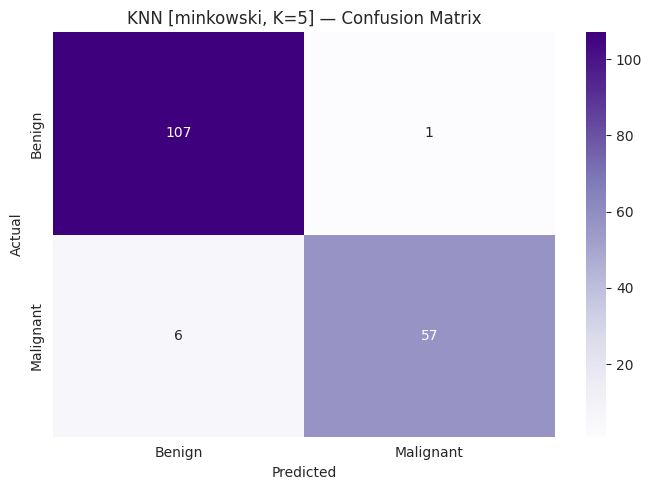

In [10]:
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Benign', 'Malignant'],
            yticklabels=['Benign', 'Malignant'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('KNN [minkowski, K=5] — Confusion Matrix')
plt.tight_layout()
plt.show()

## 10. Accuracy vs K — Line Plot

A line chart of test accuracy as a function of K helps us pick the most
stable value.  We extend the sweep up to K = 15 to visualise the trend
beyond the Lab Book's range.

Best K = 9  (accuracy = 0.9649)


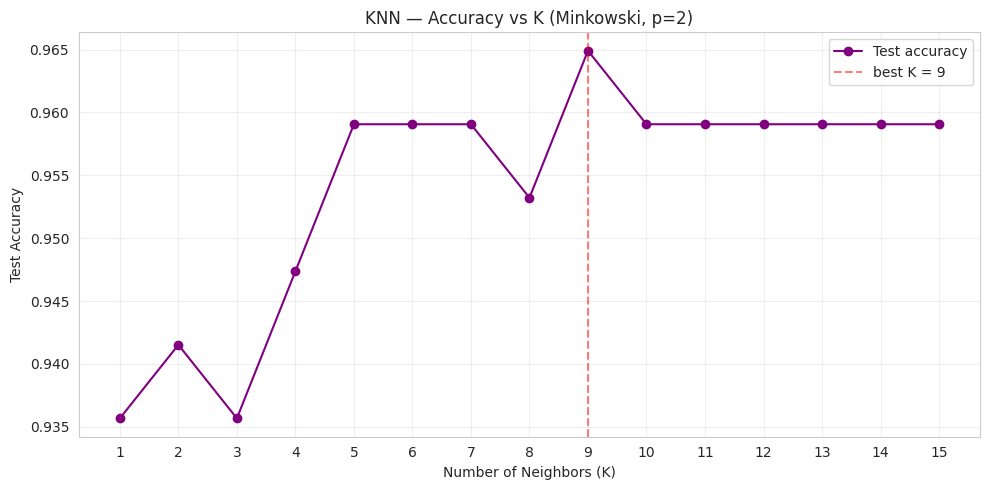

In [11]:
k_range = list(range(1, 16))
accs = []
for k in k_range:
    m = KNeighborsClassifier(n_neighbors=k, metric='minkowski', p=2)
    m.fit(X_train_scaled, y_train)
    accs.append(accuracy_score(y_test, m.predict(X_test_scaled)))

best_k = k_range[int(np.argmax(accs))]
print(f"Best K = {best_k}  (accuracy = {max(accs):.4f})")

plt.figure(figsize=(10, 5))
plt.plot(k_range, accs, 'o-', color='purple', label='Test accuracy')
plt.axvline(best_k, color='red', linestyle='--', alpha=0.5,
            label=f'best K = {best_k}')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Test Accuracy')
plt.title('KNN — Accuracy vs K (Minkowski, p=2)')
plt.xticks(k_range)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## 11. Comparison Table

Sort all K values by accuracy to confirm K=5 is among the best.

,n_neighbors,Accuracy_Score
4,5,0.959064
3,4,0.947368
1,2,0.941520
0,1,0.935673
2,3,0.935673


/tmp/ipykernel_4807/730002274.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='n_neighbors', y='Accuracy_Score', data=models_df, palette='Purples')


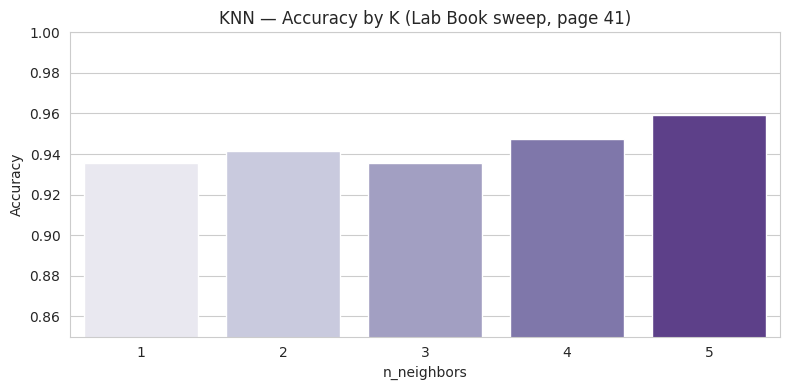

In [12]:
models_df = pd.DataFrame({
    'n_neighbors'  : [1, 2, 3, 4, 5],
    'Accuracy_Score': results,
}).sort_values('Accuracy_Score', ascending=False)
display(models_df)

# Bar chart of the 5 original K values
plt.figure(figsize=(8, 4))
sns.barplot(x='n_neighbors', y='Accuracy_Score', data=models_df, palette='Purples')
plt.ylim(0.85, 1.0)
plt.ylabel('Accuracy')
plt.title('KNN — Accuracy by K (Lab Book sweep, page 41)')
plt.tight_layout()
plt.show()

## 📝 Exercises (Lab Book §9.6, page 43)

> Submit the Colab link or GitHub link or any `.ipynb` file for the exercises.

1. **Hand-written digit recognition.** Given enough samples of hand-written
   digits, use a KNN classifier to identify a new digit based on visual
   similarity to the sample data.  Use the MNIST dataset (or scikit-learn's
   `load_digits` for a smaller-scale experiment).
   *Reference:* [GitHub — pbharrin/machinelearninginaction](https://github.com/pbharrin/machinelearninginaction)
2. **Euclidean distance computation.** For the following dataset, calculate
   the Euclidean distance between a new entry and the existing values and
   predict the class of the new entry.

| Brightness | Saturation | Class |
|------------|------------|-------|
| 40 | 20 | Red |
| 50 | 50 | Blue |
| 60 | 90 | Blue |
| 10 | 25 | Red |
| 70 | 70 | Blue |
| 60 | 10 | Red |
| 25 | 80 | Blue |


## 📚 Key Takeaways

- **KNN** is a simple, instance-based, lazy-learning algorithm — no explicit
  training phase, all computation happens at prediction time.
- **Standardise features** before KNN; otherwise features with large ranges
  dominate the distance computation.
- **Choosing K:** small K → low bias / high variance (overfitting); large K →
  high bias / low variance (under-fitting).  A common heuristic is `K = √N`.
- **Distance:** Minkowski with `p=2` is Euclidean (default); `p=1` is
  Manhattan / city-block distance.
- **Pros:** simple, no assumptions about data distribution, captures
  non-linear decision boundaries.
- **Cons:** slow at prediction time on large datasets; sensitive to feature
  scaling and to irrelevant features.


## 🔗 References

- Lab Activity Book (23CSE301), §9 K-Nearest Neighbors, page 38–43.
- Scikit-learn user guide — Nearest Neighbors:
  <https://scikit-learn.org/stable/modules/neighbors.html>
- UCI ML Repository — Wisconsin Diagnostic Breast Cancer (WDBC):
  <https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic>
